In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

data_dir = "/gpfs/projects/CascanteBonillaGroup/thinguyen/datasets/FFHQ256/processed/hairstep"
img_id = "00001.png"


resized_img = cv2.imread(f"{data_dir}/resized_img/{img_id}")
resized_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)
print(resized_img.shape)

plt.imshow(resized_img)

In [ ]:
hair_mask = cv2.imread(f"{data_dir}/seg/{img_id}", cv2.IMREAD_GRAYSCALE) / 255
# hair_mask = cv2.cvtColor(hair_mask, cv2.COLOR_BGR2RGB)
print(hair_mask.shape)

plt.imshow(hair_mask, cmap='gray')
plt.show()

In [ ]:
hair_mask_3c = np.stack([hair_mask]*3, axis=-1)
hair_region = resized_img * hair_mask_3c

plt.imshow(hair_region.astype(np.uint8))
plt.axis('off')
plt.show()

In [ ]:
rest_mask_3c = 1 - np.stack([hair_mask]*3, axis=-1)
rest_region = resized_img * rest_mask_3c

plt.imshow(rest_region.astype(np.uint8))
plt.axis('off')
plt.show()

Check strand map

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
data = np.load("/gpfs/projects/CascanteBonillaGroup/thinguyen/storage/smirk/samples/00000_strands.npy")
data = data[0]
print(np.max(data), np.min(data))
print(np.unique(data[0]))
print(np.unique(data[1]))
print(np.unique(data[2]))

1.0 0.0
[0.  0.5 1. ]
[0.         0.00131731 0.00137388 ... 0.7160996  0.7309342  0.77413714]
[0.         0.05966542 0.0934381  ... 0.83292705 0.85674876 0.89220625]


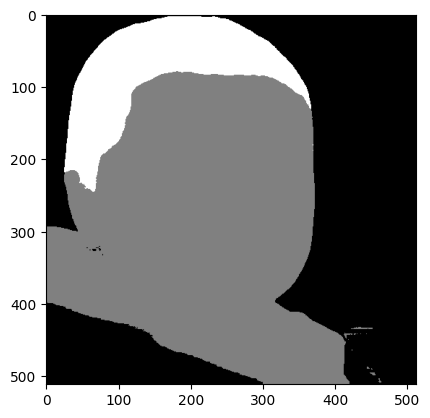

In [4]:
plt.imshow(data[0, :, :] * 255, cmap='gray')
plt.show()

Red = binary (0: background, 0.5: face/body, 1: hair)
O(x) = (M(x), O_{2D}/2 + 0.5)

In [5]:
# normalized direction, should be in [-1, 1]
green_c = (data[1] - 0.5) * 2       # x (to right)
blue_c = (data[2] - 0.5) * 2        # y (down)

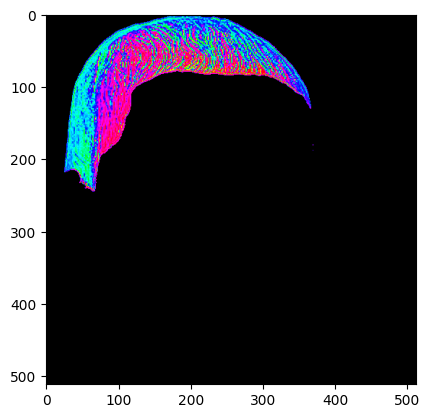

In [6]:
# compute angle 
theta = np.arctan2(-blue_c, green_c)     # in [-pi, pi]

# convert to 0-360
theta = (theta + 2*np.pi) % (2*np.pi)
theta = (2*np.pi - theta) % (2*np.pi)   # counter clockwise, 90 on the left

# hue mapping
h = theta / (2*np.pi)
s = np.ones_like(h)
v = np.ones_like(h)

hsv = np.stack([h, s, v], axis=-1)
rgb = cv2.cvtColor((hsv*255).astype(np.uint8), cv2.COLOR_HSV2RGB)

# apply hair mask
mask = (data[0] > 0.75).astype(np.float32)
rgb = (rgb * mask[...,None]).astype(np.uint8)
plt.imshow(rgb)
plt.show()


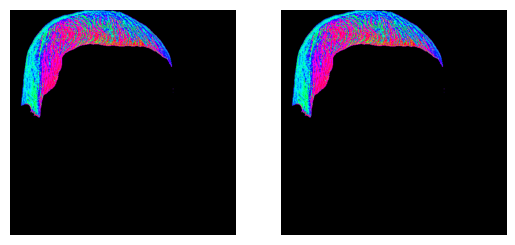

In [10]:
plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb)
plt.axis('off')
plt.savefig('test.png')

In [8]:
cv2.imwrite('test.png', cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB))

True

# CHECK angle

In [ ]:
import textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def dir_to_rgb(green, blue):
    """
    green, blue: direction components (x, y in image coords: x right, y down)
    returns: RGB triple in [0,1]
    """
    # 1) compute angle, correcting for image coordinates (y down)
    theta = np.arctan2(-blue, green) # flip y
    theta = (theta + 2*np.pi) % (2*np.pi) # [0, 2pi]

    # color wheel is counter clockwise, e.g., 90 on the left
    theta = (2*np.pi - theta) % (2*np.pi)

    # 2) map to HSV: hue in [0,1]
    h = theta / (2*np.pi)
    s = 1.0
    v = 1.0
    return mcolors.hsv_to_rgb([h, s, v])

vectors = {
    "Right (0)": (1, 0),
    "Up (90)": (0, -1),
    "Left (180)": (-1, 0),
    "Down (270)": (0, 1),
    "Up-right (45)": (1, -1),
    "Up-left (135)": (-1, -1),
    "Down-left (225)": (-1, 1),
    "Down-right (315)": (1, 1),
}

fig, ax = plt.subplots(figsize=(10, 2))
for i, (name, (G, B)) in enumerate(vectors.items()):
    rgb = dir_to_rgb(G, B)
    ax.add_patch(plt.Rectangle((i, 0), 10, 1, color=rgb))
    
    name_wrapped = "\n".join(textwrap.wrap(name, 10))
    ax.text(i+0.5, 1.2, name_wrapped, ha='center', va='center', fontsize=10, color='black')
ax.set_xlim(0, len(vectors))
ax.set_ylim(0, 1.5)
ax.axis('off')
plt.show()
